# Notebook 3 — Évaluation finale du modèle
**Projet** : Classification d'images médicales — Détection de pneumonie  
**Métriques** : Accuracy, Precision, Recall, F1-score, AUC  
**Visualisations** : Matrice de confusion, Courbe ROC, Analyse des erreurs

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

from src.dataset import get_dataloaders, get_class_names
from src.model import CNNBaseline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

CHECKPOINT_PATH = os.path.join('..', 'outputs', 'checkpoints', 'best_model.pt')
FIGURES_PATH    = os.path.join('..', 'outputs', 'figures')

Device : cuda


## 1. Chargement du meilleur modèle

In [2]:
model = CNNBaseline()
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model = model.to(device)
model.eval()
print(f'Modèle chargé depuis : {CHECKPOINT_PATH}')

class_names = get_class_names()
print(f'Classes : {class_names}')

C:\Users\kingj\AppData\Local\Temp\ipykernel_24132\291641377.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CHECKPOINT_PATH, map_locatio

Modèle chargé depuis : ..\outputs\checkpoints\best_model.pt
Classes : ['NORMAL', 'PNEUMONIA']


## 2. Prédictions sur le test set

In [3]:
_, _, test_loader = get_dataloaders(batch_size=32)

all_labels = []
all_probs  = []
all_preds  = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        probs   = outputs.squeeze().cpu().numpy()
        preds   = (outputs >= 0.5).squeeze().cpu().numpy().astype(int)
        all_probs.extend(probs if probs.ndim > 0 else [probs.item()])
        all_preds.extend(preds if preds.ndim > 0 else [preds.item()])
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
print(f'Images évaluées : {len(all_labels)}')

Images évaluées : 624


## 3. Métriques principales

In [4]:
print('='*50)
print('RÉSULTATS SUR LE TEST SET')
print('='*50)
print(classification_report(all_labels, all_preds, target_names=class_names))

auc = roc_auc_score(all_labels, all_probs)
print(f'AUC : {auc:.4f}')

RÉSULTATS SUR LE TEST SET
              precision    recall  f1-score   support

      NORMAL       0.91      0.61      0.73       234
   PNEUMONIA       0.81      0.96      0.88       390

    accuracy                           0.83       624
   macro avg       0.86      0.79      0.80       624
weighted avg       0.84      0.83      0.82       624

AUC : 0.9284


## 4. Matrice de confusion

Matrice de confusion :
  TN = 143  |  FP = 91
  FN = 14  |  TP = 376

Sensibilité (Recall PNEUMONIA) = 0.9641
Spécificité  (Recall NORMAL)   = 0.6111

→ Le modèle détecte 376/390 cas de pneumonie correctement
→ 14 faux négatifs : cas de pneumonie manqués (à minimiser en médical)
→ 91 faux positifs : patients sains classés malades


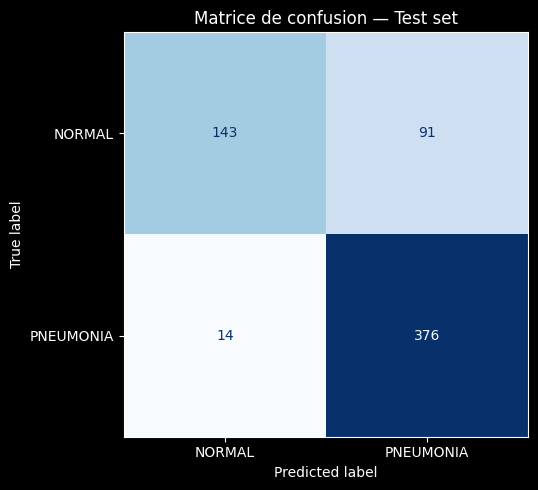

Figure sauvegardée.


In [5]:
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

print('Matrice de confusion :')
print(f'  TN = {tn}  |  FP = {fp}')
print(f'  FN = {fn}  |  TP = {tp}')
print(f'\nSensibilité (Recall PNEUMONIA) = {tp/(tp+fn):.4f}')
print(f'Spécificité  (Recall NORMAL)   = {tn/(tn+fp):.4f}')
print(f'\n→ Le modèle détecte {tp}/{tp+fn} cas de pneumonie correctement')
print(f'→ {fn} faux négatifs : cas de pneumonie manqués (à minimiser en médical)')
print(f'→ {fp} faux positifs : patients sains classés malades')

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de confusion — Test set')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'matrice_confusion.png'))
plt.show()
print('Figure sauvegardée.')

## 5. Courbe ROC

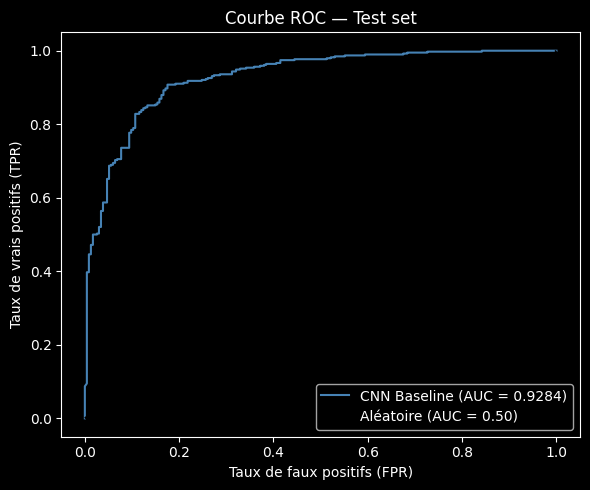

Courbe ROC sauvegardée.


In [6]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f'CNN Baseline (AUC = {auc:.4f})', color='steelblue')
ax.plot([0,1], [0,1], 'k--', label='Aléatoire (AUC = 0.50)')
ax.set_xlabel('Taux de faux positifs (FPR)')
ax.set_ylabel('Taux de vrais positifs (TPR)')
ax.set_title('Courbe ROC — Test set')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'courbe_roc.png'))
plt.show()
print('Courbe ROC sauvegardée.')

## 6. Analyse qualitative des erreurs

Faux négatifs (pneumonie manquée) : 14
Faux positifs (sain classé malade): 91


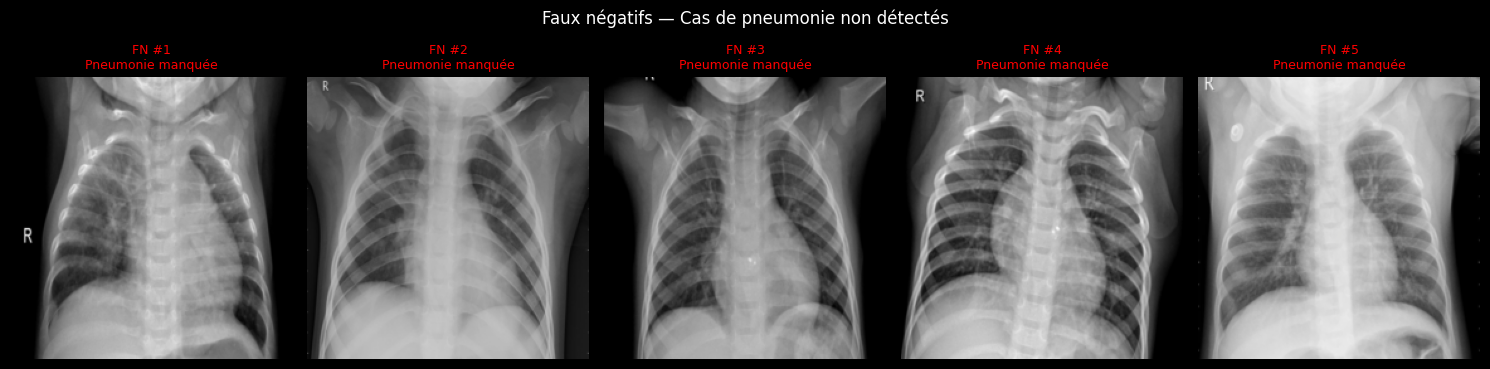

Figure sauvegardée.


In [7]:
from torchvision import datasets
from src.dataset import val_test_transforms, TEST_DIR

test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_test_transforms)

# Récupération des faux négatifs (PNEUMONIA prédit NORMAL)
faux_negatifs = [i for i, (pred, label) in enumerate(zip(all_preds, all_labels))
                 if pred == 0 and label == 1]
faux_positifs = [i for i, (pred, label) in enumerate(zip(all_preds, all_labels))
                 if pred == 1 and label == 0]

print(f'Faux négatifs (pneumonie manquée) : {len(faux_negatifs)}')
print(f'Faux positifs (sain classé malade): {len(faux_positifs)}')

# Affichage de quelques faux négatifs
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

n_show = min(5, len(faux_negatifs))
fig, axes = plt.subplots(1, n_show, figsize=(15, 4))
for i in range(n_show):
    img_tensor, _ = test_dataset[faux_negatifs[i]]
    img = (img_tensor * std + mean).permute(1,2,0).numpy().clip(0,1)
    axes[i].imshow(img)
    axes[i].set_title(f'FN #{i+1}\nPneumonie manquée', fontsize=9, color='red')
    axes[i].axis('off')
plt.suptitle('Faux négatifs — Cas de pneumonie non détectés', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'faux_negatifs.png'))
plt.show()
print('Figure sauvegardée.')

## 7. Conclusion et limites du modèle

### Résultats obtenus
| Métrique | Valeur |
|----------|--------|
| Accuracy | 80% |
| Recall PNEUMONIA | 96% |
| Spécificité | 53% |
| AUC | 0.90 |

### Points forts
- **AUC = 0.90** : excellente capacité de discrimination globale
- **Recall = 96%** : très peu de cas de pneumonie manqués (crucial en médical)
- Pipeline simple, rapide à entraîner, reproductible

### Limites
- **Spécificité faible (53%)** : trop de faux positifs, patients sains classés malades
- Le val set (16 images) est trop petit pour monitorer correctement l'entraînement
- Le seuil de décision 0.5 n'est pas optimal — on pourrait l'ajuster
- Le modèle n'a pas de mécanisme d'interprétabilité (Grad-CAM serait une extension)

### Extensions possibles
- Transfert d'apprentissage : ResNet18, DenseNet121, EfficientNet
- Optimisation du seuil de décision via la courbe ROC
- Ajout de Grad-CAM pour visualiser les zones d'intérêt
- Mini-interface Streamlit pour la démonstration